## Phase space

Conservative mechanical systems evolve according to Hamilton's equations. Trajectories lie on constant-energy surfaces defined by H(p,q) = E, and the equations of motion are

$$\dot{q}_i = \frac{\partial H}{\partial p_i},\qquad
\dot{p}_i = -\frac{\partial H}{\partial q_i}.$$ 

To describe the evolution of an ensemble of classical trajectories we introduce the phase-space probability density

$$\rho(p,q,t)\,dq\,dp,$$

which gives the probability to find the system in the phase-space volume element dq dp around the point (q,p) at time t.

### Continuity equation and Liouville's theorem

Probability is conserved in phase space and therefore the density satisfies a continuity equation

$$\frac{\partial \rho(p,q,t)}{\partial t} = -\nabla\cdot J = -\nabla\cdot(\rho\,\mathbf{v}),$$

where the phase-space flux is $J=\rho\,\mathbf{v}$ and the phase-space velocity is $\mathbf{v}=(\dot{q},\dot{p})$. Using Hamilton's equations we obtain

$$\frac{\partial \rho}{\partial t} + \sum_i\left(\frac{\partial \rho}{\partial q_i}\,\dot{q}_i + \frac{\partial \rho}{\partial p_i}\,\dot{p}_i\right) + \rho\sum_i\left(\frac{\partial\dot{q}_i}{\partial q_i}+\frac{\partial\dot{p}_i}{\partial p_i}\right)=0.$$ 

For Hamiltonian dynamics the divergence of the phase-space velocity vanishes,

$$\sum_i\left(\frac{\partial\dot{q}_i}{\partial q_i}+\frac{\partial\dot{p}_i}{\partial p_i}\right)=0,$$

so the equation reduces to the material derivative

$$\frac{d\rho}{dt}=0.$$ 

This is Liouville's theorem: the phase-space density is constant along trajectories and phase-space volume is preserved under time evolution.

Equivalently, using the Poisson bracket \(\{\cdot,\cdot\}\), we can write

$$\frac{\partial \rho}{\partial t} = -\{\rho,H\} = -\sum_i\left(\frac{\partial \rho}{\partial q_i}\frac{\partial H}{\partial p_i}-\frac{\partial \rho}{\partial p_i}\frac{\partial H}{\partial q_i}\right).$$

### Illustration of Liouville's theorem

Under Hamiltonian evolution a small phase-space area element can deform but its volume remains constant. For example, consider a small rectangular patch centered at (x0, v0) with half-widths dx and dv,

$$x_0-\Delta x\le x\le x_0+\Delta x,\qquad v_0-\Delta v\le v\le v_0+\Delta v.$$ 

As the system evolves the rectangle may stretch and fold, but — for sufficiently small patches where the dynamics is locally Hamiltonian — its area (or volume in higher dimensions) is conserved.

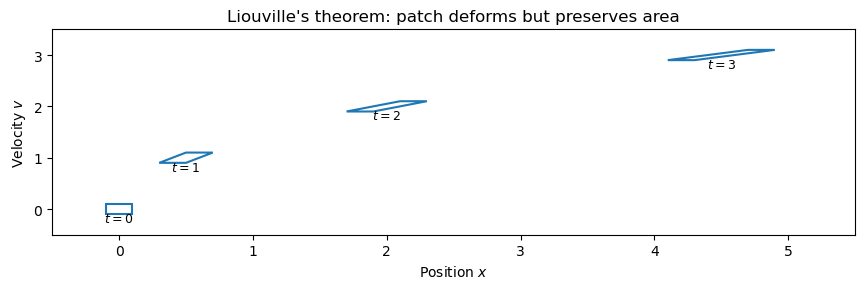

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Uniform-force Hamiltonian: H = p²/2m - ax  →  q̇ = p,  ṗ = a (constant)
a = 1.0
x0, v0 = 0.0, 0.0   # center of initial patch
dx, dv  = 0.1, 0.1  # half-widths of initial rectangular patch

corners = np.array([[x0-dx, v0-dv],
                    [x0-dx, v0+dv],
                    [x0+dx, v0+dv],
                    [x0+dx, v0-dv]])

def propagate(pts, t):
    """Evolve phase-space patch under constant acceleration for time t."""
    xs, vs = pts.T
    return np.column_stack((xs + vs*t + 0.5*a*t**2, vs + a*t))

fig, ax = plt.subplots(figsize=(9, 3))
for t in range(4):
    p = propagate(corners, t)
    cx, cy = p.mean(axis=0)
    ax.add_patch(Polygon(p, closed=True, fill=False, edgecolor='C0', lw=1.5))
    ax.text(cx, cy - 0.25, f"$t={t}$", ha='center', fontsize=9)

ax.set_xlabel("Position $x$")
ax.set_ylabel("Velocity $v$")
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 3.5)
ax.set_title("Liouville's theorem: patch deforms but preserves area")
plt.tight_layout()
plt.show()

### Phase portraits

A **phase portrait** displays all trajectories of a Hamiltonian system simultaneously — each curve is a level set $H(q,p) = \text{const}$. The topology of the portrait reveals the qualitative dynamics:

- **Closed orbits** — bounded (oscillatory) motion
- **Open orbits** — unbounded motion  
- **Separatrix** — the special trajectory dividing these two regimes

Below we illustrate two canonical systems: a nonlinear pendulum and a harmonic oscillator.

In [ ]:
# Nonlinear pendulum: H = p²/2 - cos(q)  →  q̇ = p,  ṗ = -sin(q)
xmax = 2 * np.pi
ymax = 2.0
X, Y = np.meshgrid(np.linspace(-xmax, xmax, 200), np.linspace(-ymax, ymax, 100))

fig, ax = plt.subplots(figsize=(8, 4))
ax.streamplot(X, Y, Y, -np.sin(X), density=1.2, color='C0', linewidth=0.8)
ax.set_xlabel("$q$ (angle)")
ax.set_ylabel("$p$ (momentum)")
ax.set_xlim(-xmax, xmax)
ax.set_ylim(-ymax, ymax)
ax.set_xticks([-np.pi, 0, np.pi], [r"$-\pi$", "0", r"$\pi$"])
ax.set_title("Pendulum phase portrait — separatrix divides bounded and unbounded orbits")
plt.tight_layout()
plt.show()

### Counting of states in phase space

**Quantum mechanics.**

- In quantum mechanics energy levels are discrete for many bound systems, so counting states is straightforward: we count eigenstates or occupation numbers.

- Example: independent one-dimensional harmonic oscillators have energies

$$E=\sum_j\Big(n_j+\tfrac{1}{2}\Big)\hbar\omega.$$ 

For a single oscillator the number of states up to energy E scales as

$$N_E\approx\frac{E}{\hbar\omega}\qquad(\text{for }E\gg\hbar\omega).$$

The energy surface of the harmonic oscillator is an **ellipse** in $(q,p)$-space. The area enclosed at energy $E$ is $V(E)=2\pi E/\omega$, and dividing by $h$ recovers the semiclassical count $N(E)\approx E/\hbar\omega$.

**Classical mechanics.**

In classical mechanics energy is continuous, so we quantify the "number of states" by the phase-space volume occupied by the system at a given energy divided by a unit cell of size h per degree of freedom. For a single 1D harmonic oscillator the energy surface is an ellipse in (q,p)-space:

$$\frac{p^2}{2mE} + \frac{q^2}{2E/(m\omega^2)} = 1,$$

and the area of this ellipse is

$$V(E)=\pi\sqrt{2mE}\,\sqrt{\frac{2E}{m\omega^2}}=\frac{2\pi E}{\omega}.$$ 

To match the semiclassical counting from quantum mechanics we divide the classical phase-space volume by Planck's constant h to obtain the number of quantum states represented by that volume:

$$N_E\simeq\frac{V(E)}{h}=\frac{2\pi E}{\omega h}.$$ 

More generally, each degree of freedom contributes a factor of h to the elementary cell in phase space, so counting states requires dividing by $h^{f}$ where f is the number of degrees of freedom.

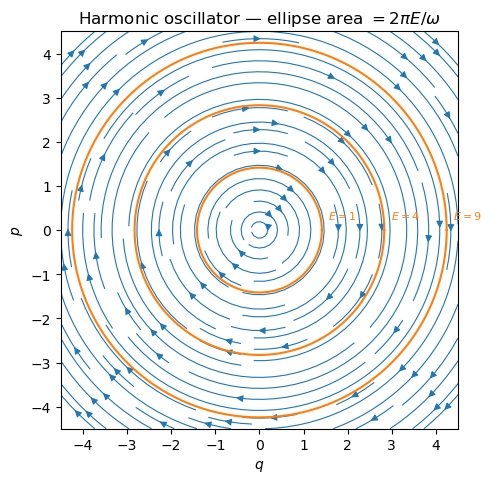

In [2]:
# Harmonic oscillator: H = p²/2 + q²/2  (m=1, ω=1)  →  q̇ = p,  ṗ = -q
xmax = 4.5
grid = np.linspace(-xmax, xmax, 200)
X, Y = np.meshgrid(grid, grid)

fig, ax = plt.subplots(figsize=(5, 5))
ax.streamplot(X, Y, Y, -X, density=1.2, color='C0', linewidth=0.8)

# Overlay constant-energy ellipses: area = 2πE/ω connects to state counting
theta = np.linspace(0, 2*np.pi, 300)
for E in [1, 4, 9]:
    r = np.sqrt(2*E)
    ax.plot(r*np.cos(theta), r*np.sin(theta), 'C1', lw=1.5)
    ax.annotate(f"$E={E}$", xy=(r, 0), xytext=(r + 0.15, 0.25), fontsize=8, color='C1')

ax.set_aspect('equal')
ax.set_xlabel("$q$")
ax.set_ylabel("$p$")
ax.set_xlim(-xmax, xmax)
ax.set_ylim(-xmax, xmax)
ax.set_title("Harmonic oscillator — ellipse area $= 2\\pi E/\\omega$")
plt.tight_layout()
plt.show()

**General expression for the number of states (classical).**

- For a system of N indistinguishable particles with 3N phase-space degrees of freedom the number of microstates with total energy less than or equal to E is given (semiclassically) by

$$N(E)=\frac{1}{N!\,h^{3N}}\int_{H(p^N,q^N)\le E} dp^N\,dq^N.$$ 

- Using the Heaviside step function $\Theta$ this can be written without explicit integration limits as

$$N(E)=\frac{1}{N!\,h^{3N}}\int dp^N\,dq^N\,\Theta\big(E-H(p^N,q^N)\big).$$

- The factor 1/N! accounts for particle indistinguishability in the classical counting and has important thermodynamic consequences.

### Density of states

For macroscopic systems it is often more convenient to work with the density of states, which measures the number of microstates per unit energy.

$$\Omega(E)=\frac{dN(E)}{dE},\qquad N(E)\approx\Omega(E)\,\Delta E.$$ 

Differentiating the integral representation of N(E) with respect to E brings down a delta function and yields the microcanonical density of states

$$\boxed{\;\Omega(E)=\frac{1}{N!\,h^{3N}}\int dp^N\,dq^N\,\delta\big(E-H(p^N,q^N)\big)\;}$$

Here we used that the derivative of the Heaviside function is the Dirac delta, \(d\Theta(x)/dx=\delta(x)\). The density of states is the fundamental quantity for constructing microcanonical averages and for connecting to thermodynamic entropy.